⏳ Loading dataset...
✅ Target Mapping: {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Moderate': np.int64(3)}
🚀 Training Random Forest Model...
🏆 Model Accuracy: 99.23%

--- Classification Report ---

              precision    recall  f1-score   support

    Critical       1.00      0.70      0.82        10
        High       1.00      0.97      0.98        64
         Low       1.00      1.00      1.00       595
    Moderate       0.97      1.00      0.98       111

    accuracy                           0.99       780
   macro avg       0.99      0.92      0.95       780
weighted avg       0.99      0.99      0.99       780



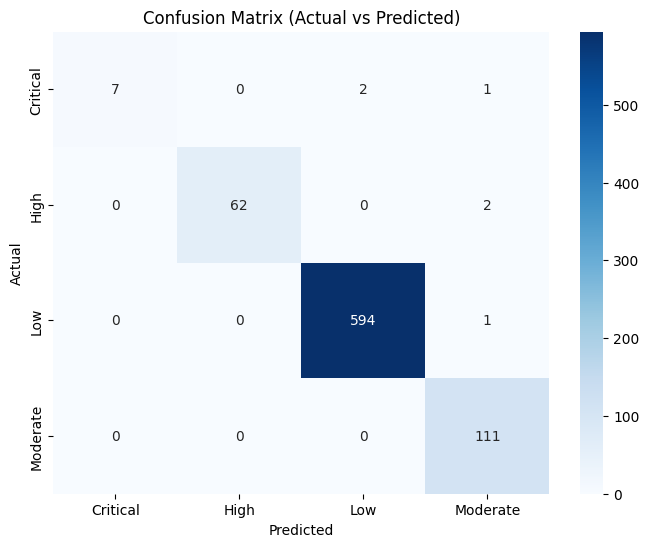

/tmp/ipython-input-1534272039.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=features, palette="viridis")


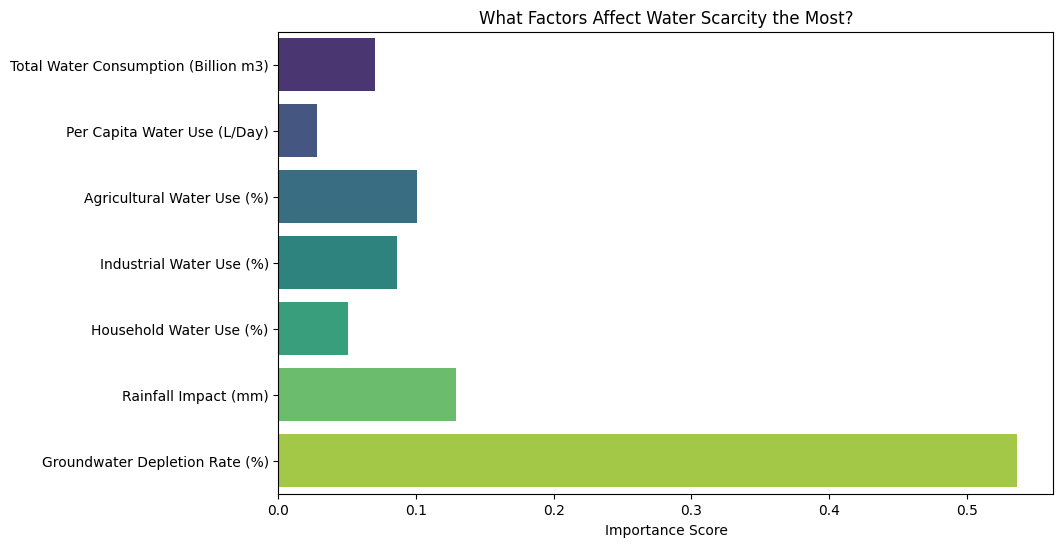

⬇️ Downloading files for your GitHub...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pickle
from google.colab import files

# --- 1. DATA LOADING ---
print("⏳ Loading dataset...")
# Ab file pakka wahin hai, isliye ye chal jayega
df = pd.read_csv('global_water_consumption_2000_2025.csv')

# --- 2. DATA PREPROCESSING ---
# Convert Categories to Numbers
le_country = LabelEncoder()
le_scarcity = LabelEncoder()

df['Country_Code'] = le_country.fit_transform(df['Country'])
df['Scarcity_Label'] = le_scarcity.fit_transform(df['Water Scarcity Level'])

# Save the mapping
scarcity_mapping = dict(zip(le_scarcity.classes_, le_scarcity.transform(le_scarcity.classes_)))
print(f"✅ Target Mapping: {scarcity_mapping}")

# Select Features
features = [
    'Total Water Consumption (Billion m3)',
    'Per Capita Water Use (L/Day)',
    'Agricultural Water Use (%)',
    'Industrial Water Use (%)',
    'Household Water Use (%)',
    'Rainfall Impact (mm)',
    'Groundwater Depletion Rate (%)'
]

X = df[features]
y = df['Scarcity_Label']

# --- 3. TRAIN MODEL ---
print("🚀 Training Random Forest Model...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 4. EVALUATION & GRAPHS ---
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
print(f"🏆 Model Accuracy: {accuracy * 100:.2f}%")

# Generate Classification Report
print("\n--- Classification Report ---\n")
print(classification_report(y_test, y_pred, target_names=le_scarcity.classes_))

# GRAPH 1: Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_scarcity.classes_, yticklabels=le_scarcity.classes_)
plt.title("Confusion Matrix (Actual vs Predicted)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("confusion_matrix.png") # Save image
plt.show()

# GRAPH 2: Feature Importance
plt.figure(figsize=(10, 6))
importance = model.feature_importances_
sns.barplot(x=importance, y=features, palette="viridis")
plt.title("What Factors Affect Water Scarcity the Most?")
plt.xlabel("Importance Score")
plt.savefig("feature_importance.png") # Save image
plt.show()

# --- 5. AUTOMATIC DOWNLOAD ---
print("⬇️ Downloading files for your GitHub...")
with open('water_scarcity_model.pkl', 'wb') as f:
    pickle.dump(model, f)

files.download('water_scarcity_model.pkl')
files.download('confusion_matrix.png')
files.download('feature_importance.png')